In [1]:
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline 
plt.rcParams['figure.figsize'] = [16, 10]

import sys
sys.path.append('/Users/kai/src/psc/python')
import psc

In [2]:
ds1 = xr.open_dataset("/Users/kai/src/psc/build-spack-ubuntu2/pfd.000000500.bp", engine='pscadios2', species_names=['e', 'i'],
                    length=[1, 200, 50], corner=[0, 0, -25])
ds2 = xr.open_dataset("/Users/kai/src/psc/build-spack-ubuntu2/pfd_moments.000000500.bp", engine='pscadios2', 
                    length=[1, 200, 50], corner=[0, 0, -25],
                     species_names=['e', 'i', 'e_bg', 'i_bg'])
ds = xr.merge([ds1, ds2])
ds

<xarray.Dataset>
Dimensions:   (x: 1, y: 512, z: 128)
Coordinates:
  * x         (x) float64 0.0
  * y         (y) float64 0.0 0.3906 0.7812 1.172 ... 198.4 198.8 199.2 199.6
  * z         (z) float64 -25.0 -24.61 -24.22 -23.83 ... 23.44 23.83 24.22 24.61
Data variables: (12/61)
    jx_ec     (x, y, z) <class 'numpy.float32'> ...
    jy_ec     (x, y, z) <class 'numpy.float32'> ...
    jz_ec     (x, y, z) <class 'numpy.float32'> ...
    ex_ec     (x, y, z) <class 'numpy.float32'> ...
    ey_ec     (x, y, z) <class 'numpy.float32'> ...
    ez_ec     (x, y, z) <class 'numpy.float32'> ...
    ...        ...
    txx_i_bg  (x, y, z) <class 'numpy.float32'> ...
    tyy_i_bg  (x, y, z) <class 'numpy.float32'> ...
    tzz_i_bg  (x, y, z) <class 'numpy.float32'> ...
    txy_i_bg  (x, y, z) <class 'numpy.float32'> ...
    tyz_i_bg  (x, y, z) <class 'numpy.float32'> ...
    tzx_i_bg  (x, y, z) <class 'numpy.float32'> ...
Attributes:
    ib:       [0 0 0]
    im:       [  1 128 128]
    step:     500
    time:     103.58009490037318

In [3]:
def plot_fields(fldnames, fld_kwargs=None):
    fig, axs = plt.subplots(len(fldnames), 1)
    if len(fldnames) == 1: axs = [axs]
    for i, fldname in enumerate(fldnames):
        fld = ds[fldname]
        if fld_kwargs:
            kwargs = fld_kwargs[i]
        else:
            kwargs = {}
        fld.T.plot(ax=axs[i], **kwargs)
        axs[i].set_aspect('equal')

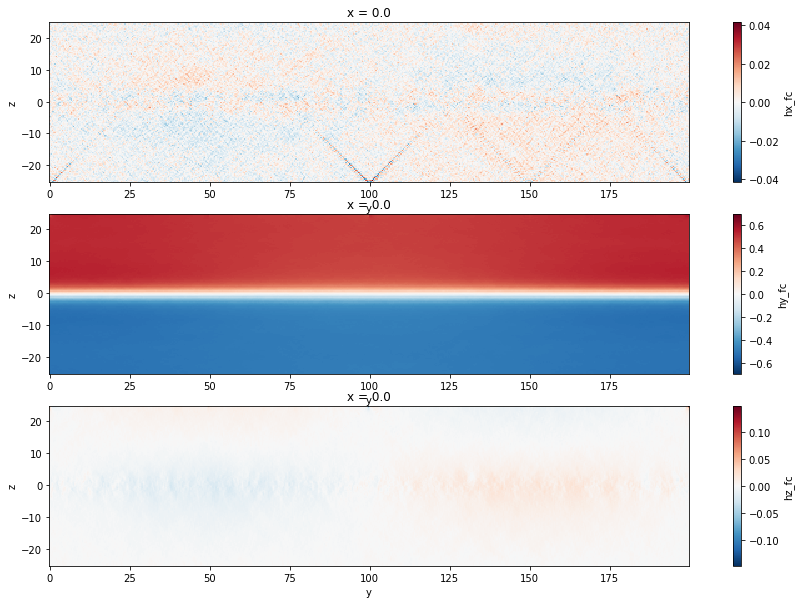

In [4]:
plot_fields(['hx_fc', 'hy_fc', 'hz_fc'])

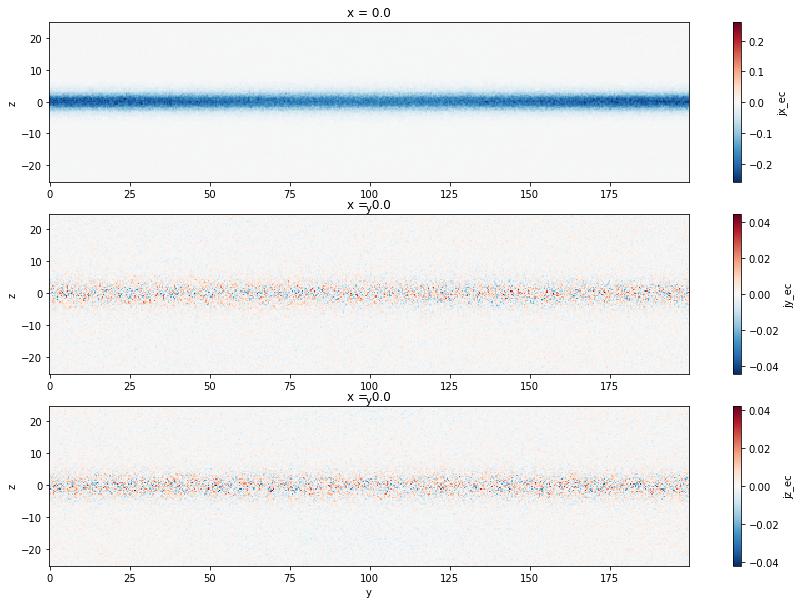

In [5]:
plot_fields(['jx_ec', 'jy_ec', 'jz_ec'])

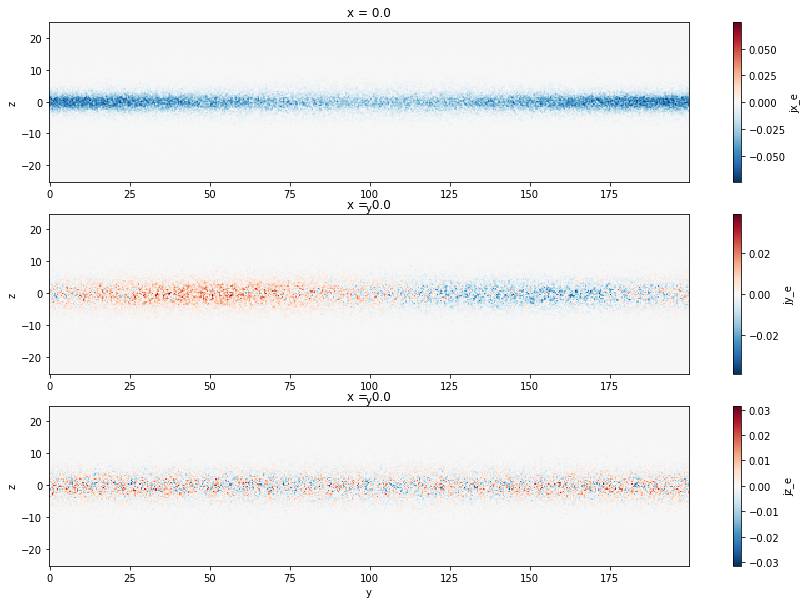

In [6]:
plot_fields(['jx_e', 'jy_e', 'jz_e'])

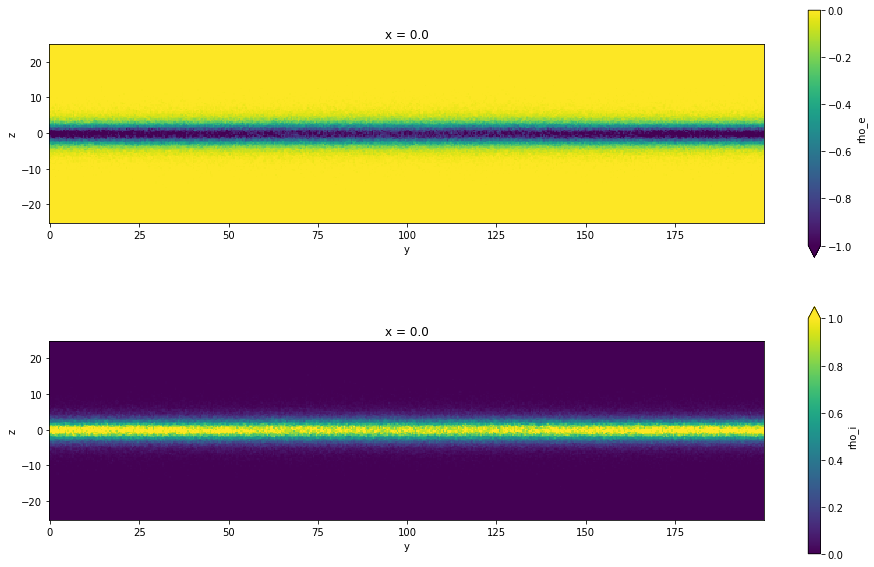

In [7]:
plot_fields(['rho_e', 'rho_i'], 
            fld_kwargs=[{"vmin": -1, "vmax": 0}, 
                        {"vmin": 0, "vmax": 1}])

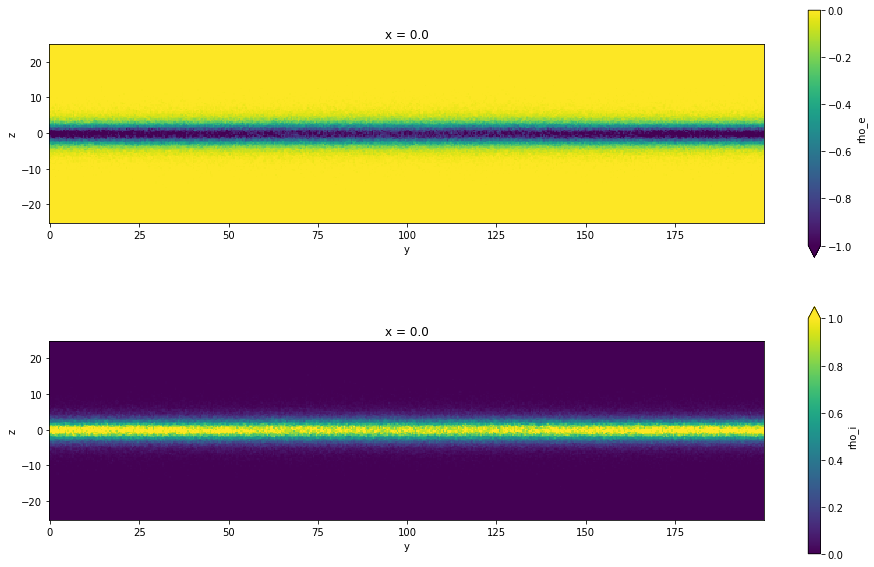

In [8]:
plot_fields(['rho_e', 'rho_i'], 
            fld_kwargs=[{"vmin": -1, "vmax": 0}, 
                        {"vmin": 0, "vmax": 1}])

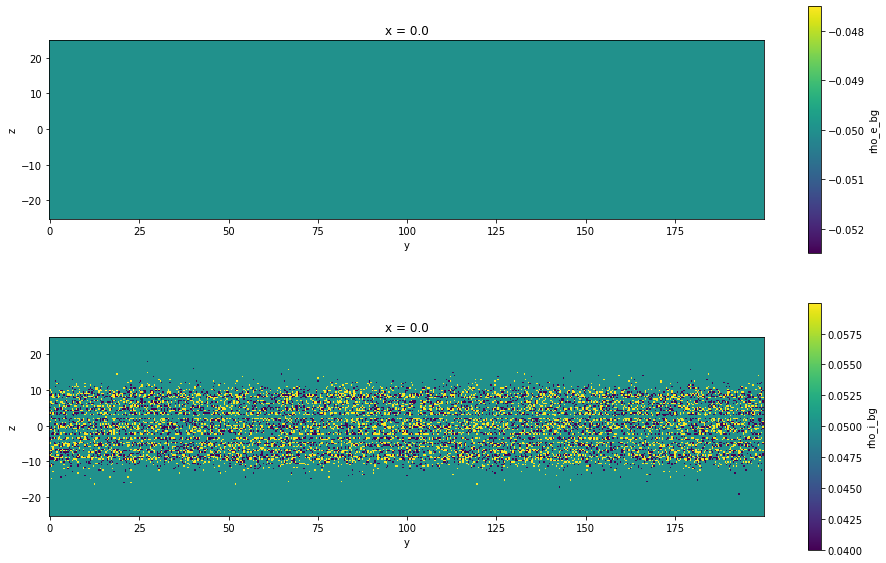

In [30]:
plot_fields(['rho_e_bg', 'rho_i_bg']) 